### 1. Dimensionality Reduction (PCA) : 
In the real world, your data will almost never have just 2 features. What happens when your dataset has 10, 50, or 100 features?

> The Visual Limit: Humans cannot visualize beyond 3 dimensions.
Curse of Dimensionality: As dimensions increase, distances lose their meaning, breaking distance-based algorithms like K-Means.
Principal Component Analysis (PCA) is our compression algorithm. It mathematically transforms high-dimensional tables into a smaller set of dense "summary" features, while keeping as much of the original "variance" (information) as possible.

In [2]:
from sklearn.decomposition import PCA

# loading the tools 
import pandas as pd 
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt

# importing the machine learning tools
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
import warnings
warnings.filterwarnings('ignore')

In [3]:


# 1. Create a complex dataset with 10 features
X_high_dim, _ = make_blobs(n_samples=500, centers=4, n_features=10, random_state=42)

# Let's load this into a Pandas DataFrame so we can visually inspect what high dimensional data looks like
feature_names = [f"Feature_{i+1}" for i in range(10)]
df_high_dim = pd.DataFrame(X_high_dim, columns=feature_names)

print("============================== BEFORE PCA ==============================")
print(f"Data Shape: {df_high_dim.shape}")
print("Look at all these columns! We cannot plot a 10-dimensional graph to see the clusters.\n")
display(df_high_dim.head())

============================== BEFORE PCA ==============================
Data Shape: (500, 10)
Look at all these columns! We cannot plot a 10-dimensional graph to see the clusters.



,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10
0,-8.399397,10.106501,7.000301,-4.683068,-6.390022,-7.213784,-4.078222,-0.249774,-2.036278,-4.319936
1,1.305743,-6.036129,-8.732893,7.382955,9.733340,5.590026,-3.026578,-8.045232,4.080082,-2.154519
2,-8.849500,10.013565,5.713414,-4.667236,-6.899464,-5.523852,-3.547868,2.333312,-1.584566,-4.524734
3,2.497500,-7.748965,-5.165662,-4.635389,-0.528950,4.138716,-5.911180,0.021241,2.527434,-9.373037
4,2.948741,-8.448854,-8.653477,9.536047,11.169288,5.686181,-3.583266,-9.850421,1.292704,-0.352176


In [4]:
# 2. Scale the data (Always required before PCA!)
X_high_scaled = StandardScaler().fit_transform(df_high_dim)

# 3. Apply PCA to compress from 10 features down to just 2 principal components
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_high_scaled)

# Let's load the results into a NEW DataFrame to see what PCA actually did
df_pca = pd.DataFrame(X_reduced, columns=["Principal Component 1", "Principal Component 2"])

print("\n============================== AFTER PCA ==============================")
print(f"Data Shape: {df_pca.shape}")
print("The 10 distinct columns have been mathematically compressed into 2 summary columns:\n")
display(df_pca.head())


============================== AFTER PCA ==============================
Data Shape: (500, 2)
The 10 distinct columns have been mathematically compressed into 2 summary columns:



,Principal Component 1,Principal Component 2
0,2.626483,-1.706994
1,-3.385801,0.060349
2,2.544746,-1.702096
3,-1.350849,-0.877884
4,-3.425423,-0.052871


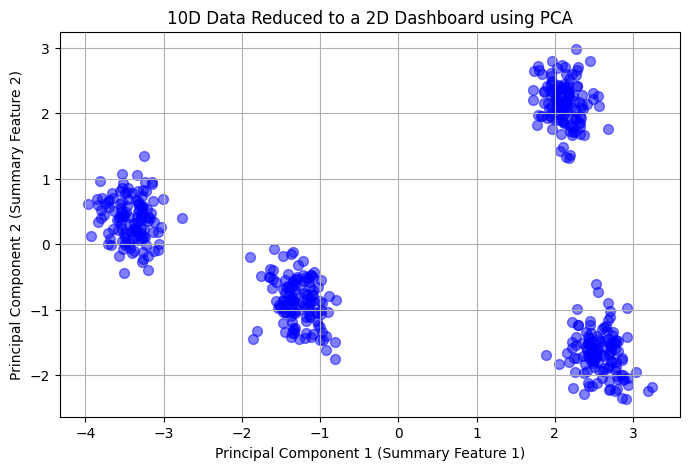

In [5]:
# 4. Because we only have 2 columns now, we can finally visualize our data!
plt.figure(figsize=(8, 5))
plt.scatter(df_pca["Principal Component 1"], df_pca["Principal Component 2"], c='blue', alpha=0.5, s=50)
plt.title("10D Data Reduced to a 2D Dashboard using PCA")
plt.xlabel("Principal Component 1 (Summary Feature 1)")
plt.ylabel("Principal Component 2 (Summary Feature 2)")
plt.grid(True)
plt.show()